# EDA & Tiền xử lý — Riboflavin (p ≫ n)

Bài toán **hồi quy**: dự đoán mức sản xuất riboflavin `y` (log) từ **biểu hiện gen**.
Bộ **71 mẫu × 4.088 gen** → bài toán kinh điển **p ≫ n** (p/n ≈ 57,6): rất ít mẫu, cực nhiều feature →
**OLS sẽ overfit hoàn hảo** (train R²=1) và **bắt buộc phải feature selection / regularization**.

> ℹ️ Bộ này **toàn biến số** (cường độ biểu hiện gen) → **không có one-hot/encoding** để đổi sang binary mapping.
> Trọng tâm tiền xử lý ở đây: kiểm tra chất lượng + **lọc gen phương sai thấp (uninformative)** + EDA cho p ≫ n.

## 0. Thiết lập môi trường
**Lý do:** Xử lý trực tiếp trên **dữ liệu gốc** `riboflavin_dataset.csv`. Trên Colab **tự mount Drive**;
`find_data_dir` tự dò thư mục. 👉 Nếu auto-detect thất bại, sửa **`DATA_DIR`** thành đường dẫn của bạn.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tu dong mount Google Drive neu chay tren Colab
try:
    import google.colab  # noqa
    if not os.path.exists('/content/drive/MyDrive'):
        from google.colab import drive
        drive.mount('/content/drive')
except ImportError:
    pass

# >>> Neu auto-detect that bai: dat DATA_DIR = duong dan thu muc chua riboflavin_dataset.csv <<<
DATA_DIR = None

def find_data_dir(marker, override=None):
    cands = ([override] if override else []) + [
        'dataset', 'Data/dataset', '.', '..',
        '/content/drive/MyDrive/AIO-Conquer02',
        '/content/drive/MyDrive/conquer1/AIO-Conquer-Data/Data/dataset',
    ]
    for p in cands:
        if p and os.path.exists(os.path.join(p, marker)):
            return p
    raise FileNotFoundError("Khong tim thay '" + marker + "'. Hay dat DATA_DIR = duong dan thu muc chua file nay.")

DATA_DIR = find_data_dir('riboflavin_dataset.csv', DATA_DIR)
print('DATA_DIR =', DATA_DIR)

# Thu muc luu hinh EDA (savefig se ghi PNG vao day de bao cao lay lai)
ASSETS_DIR = next((p for p in ['eda_assets', 'Data/eda_assets', '../eda_assets'] if os.path.isdir(p)), 'eda_assets')
os.makedirs(ASSETS_DIR, exist_ok=True)
print('ASSETS_DIR =', os.path.abspath(ASSETS_DIR))

Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/AIO-Conquer02
ASSETS_DIR = /content/eda_assets


## 1. Nạp & kiểm tra tổng quan

**Lý do:** Nắm kích thước, kiểu dữ liệu, mức độ đầy đủ; xác nhận đặc trưng p ≫ n.

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'riboflavin_dataset.csv'))
TARGET = 'y'
genes = df.drop(columns=TARGET)
print('Kich thuoc:', df.shape)
print('p/n =', round(genes.shape[1] / df.shape[0], 1), '(p =', genes.shape[1], 'gen, n =', df.shape[0], 'mau)')
print('Kieu du lieu:', df.dtypes.value_counts().to_dict())
df.iloc[:5, :6]

Kich thuoc: (71, 4089)
p/n = 57.6 (p = 4088 gen, n = 71 mau)
Kieu du lieu: {dtype('float64'): 4089}


,y,x.AADK_at,x.AAPA_at,x.ABFA_at,x.ABH_at,x.ABNA_at
0,-6.643856,8.492404,8.111451,8.320842,10.287112,8.261279
1,-6.947862,7.639380,7.239965,7.289051,9.862287,7.303497
2,-7.930160,8.088340,7.855510,7.793395,9.676720,7.098273
3,-8.287712,7.886820,7.939513,7.997588,9.680562,7.408494
4,-7.310432,6.805762,7.554522,7.609902,8.551953,7.712407


> 📊 **Phân tích:** **71 mẫu × 4.089 cột** (1 target `y` + **4.088 gen**), **toàn `float64`**. Tỉ lệ **p/n ≈ 57,6** —
> số feature gấp ~58 lần số mẫu → không gian nghiệm cực rộng, OLS sẽ nội suy hoàn hảo train và **overfit nặng**.

## 2. Chất lượng dữ liệu — missing & trùng

**Lý do:** Trước khi phân tích cần chắc dữ liệu sạch.

In [3]:
print('Tong o missing:', int(df.isna().sum().sum()))
print('So dong trung lap:', int(df.duplicated().sum()))

Tong o missing: 0
So dong trung lap: 0


> 📊 **Phân tích:** **0 missing, 0 dòng trùng** → dữ liệu microarray đã chuẩn hoá sẵn, không cần impute/khử trùng.

## 3. Phân phối target `y`

**Lý do:** Hiểu hình dạng target (log của mức sản xuất riboflavin).

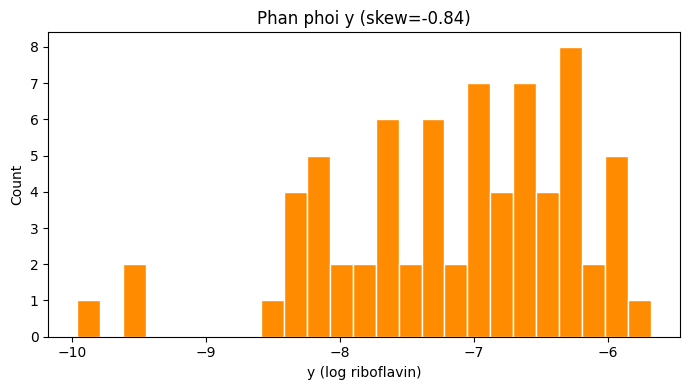

count    71.000
mean     -7.159
std       0.920
min      -9.966
25%      -7.688
50%      -6.948
75%      -6.449
max      -5.673
Name: y, dtype: float64


In [4]:
plt.figure(figsize=(7, 4))
plt.hist(df[TARGET], bins=25, color='darkorange', edgecolor='white')
plt.title('Phan phoi y (skew=' + str(round(df[TARGET].skew(),2)) + ')')
plt.xlabel('y (log riboflavin)'); plt.ylabel('Count'); plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, 'rb_y.png'), dpi=150, bbox_inches='tight'); plt.show()
print(df[TARGET].describe().round(3))

> 📊 **Phân tích:** `y` nằm trong khoảng **[−9,97; −5,67]**, **lệch trái nhẹ (skew≈−0,84)**, tập trung quanh −7. Phân
> phối gần đối xứng, không có outlier cực đoan → **giữ nguyên target**, không cần biến đổi.

## 4. Phân phối phương sai của gen

**Lý do:** Với 4.088 gen, nhiều gen biểu hiện gần như không đổi giữa các mẫu (**phương sai thấp → ít thông tin**).
Xem phân phối variance để đặt ngưỡng lọc.

Variance: min 0.0099 | median 0.1318 | max 3.4013


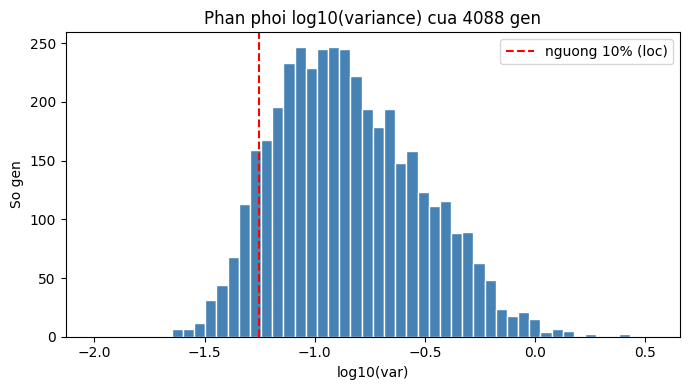

In [5]:
var = genes.var()
print('Variance: min', round(var.min(),4), '| median', round(var.median(),4), '| max', round(var.max(),4))
plt.figure(figsize=(7, 4))
plt.hist(np.log10(var), bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.log10(var.quantile(0.10)), color='red', ls='--', label='nguong 10% (loc)')
plt.title('Phan phoi log10(variance) cua 4088 gen'); plt.xlabel('log10(var)'); plt.ylabel('So gen')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, 'rb_var.png'), dpi=150, bbox_inches='tight'); plt.show()

> 📊 **Phân tích:** Phương sai gen trải rộng (**min 0,0099 → max 3,40**, median 0,132). **Không có gen phương sai = 0**,
> nhưng nhóm đuôi trái (phương sai rất thấp) gần như hằng số → đóng góp ít cho mô hình và chỉ làm tăng nhiễu/chiều.

## 5. Tương quan của gen với target

**Lý do:** Trong p ≫ n, chỉ một số ít gen thực sự liên quan tới `y`. Xem top gen mạnh nhất và phân phối |corr| tổng thể.

Top 10 gen |corr| manh nhat voi y:
x.XHLA_at    0.649
x.XHLB_at    0.628
x.YXLD_at    0.608
x.YCKE_at    0.606
x.XKDF_at    0.604
x.XKDK_at    0.603
x.XTRA_at    0.599
x.YXLE_at    0.587
x.XKDS_at    0.586
x.YXLG_at    0.583
dtype: float64

So gen |corr|<0.1 (gan nhieu): 1757 / 4088 ( 43.0 % )


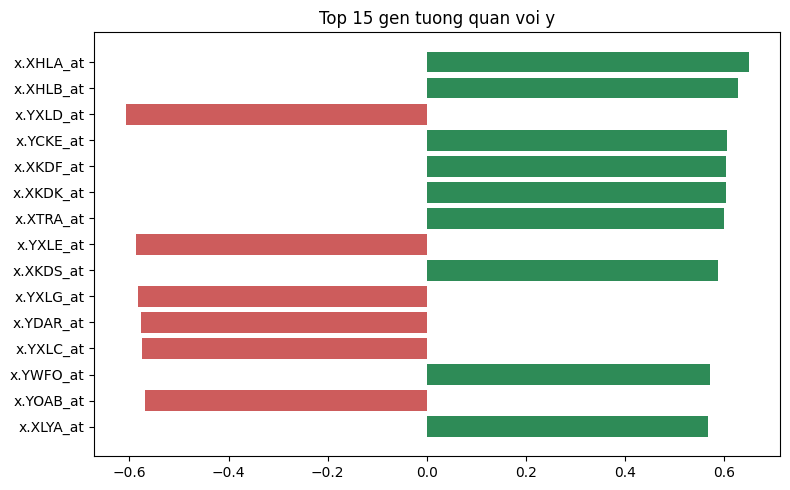

In [6]:
corr_y = genes.corrwith(df[TARGET])
abs_corr = corr_y.abs().sort_values(ascending=False)
print('Top 10 gen |corr| manh nhat voi y:')
print(abs_corr.head(10).round(3))
print('\nSo gen |corr|<0.1 (gan nhieu):', int((abs_corr < 0.1).sum()), '/', len(abs_corr),
      '(', round(100*(abs_corr<0.1).mean(),1), '% )')
plt.figure(figsize=(8, 5))
top = corr_y.reindex(abs_corr.head(15).index)
plt.barh(top.index[::-1], top.values[::-1], color=['seagreen' if v>0 else 'indianred' for v in top.values[::-1]])
plt.title('Top 15 gen tuong quan voi y'); plt.tight_layout()
plt.savefig(os.path.join(ASSETS_DIR, 'rb_topgenes.png'), dpi=150, bbox_inches='tight'); plt.show()

> 📊 **Phân tích:** Gen mạnh nhất chỉ đạt **|corr|≈0,65** (`x.XHLA_at`, `x.XHLB_at`, `x.YXLD_at`, `x.YCKE_at`...).
> **Đa số gen tương quan rất yếu với `y`** (phần lớn |corr|<0,1) → tín hiệu nằm ở **một nhúm nhỏ gen**. Đây chính là lý do
> Lasso/Boruta hữu ích: loại hàng nghìn gen nhiễu, giữ vài chục gen mang tín hiệu.

## 6. Tiền xử lý — lọc gen phương sai thấp

**Lý do:** Bỏ **10% gen phương sai thấp nhất** (gần hằng số, ít thông tin) để giảm nhiễu/chiều trước khi mô hình hoá.
**Không** đụng target. Ngưỡng nhẹ (10%) để tránh vô tình bỏ gen có ích — selection mạnh hơn để cho Lasso/Boruta lo.

> ⚠️ **Lưu ý chống leakage:** chuẩn hoá (`StandardScaler`) cho Lasso **phải fit trên train**, nên để **trong pipeline ở bước model**,
> KHÔNG scale ở đây. Lọc phương sai theo ngưỡng tương đối là thao tác **unsupervised** nên an toàn làm trước.

In [7]:
thr = var.quantile(0.10)
keep = var[var > thr].index.tolist()
df_proc = df[[TARGET] + keep].copy()
print('Nguong variance (10% quantile):', round(thr, 4))
print('Da bo', genes.shape[1] - len(keep), 'gen phuong sai thap | con lai', len(keep), 'gen')
print('Shape sau xu ly:', df_proc.shape)

Nguong variance (10% quantile): 0.0558
Da bo 409 gen phuong sai thap | con lai 3679 gen
Shape sau xu ly: (71, 3680)


## 7. Lưu dữ liệu đã xử lý

**Lý do:** Xuất bộ sạch (đã lọc gen phương sai thấp, giữ target nguyên gốc). Lưu `riboflavin_processed.csv`.

In [8]:
out = os.path.join(DATA_DIR, 'riboflavin_processed.csv')
df_proc.to_csv(out, index=False)
print('Da luu', out, '|', df_proc.shape, '| missing:', int(df_proc.isna().sum().sum()))
df_proc.iloc[:5, :6]

Da luu /content/drive/MyDrive/AIO-Conquer02/riboflavin_processed.csv | (71, 3680) | missing: 0


,y,x.AADK_at,x.AAPA_at,x.ABFA_at,x.ABH_at,x.ABNA_at
0,-6.643856,8.492404,8.111451,8.320842,10.287112,8.261279
1,-6.947862,7.639380,7.239965,7.289051,9.862287,7.303497
2,-7.930160,8.088340,7.855510,7.793395,9.676720,7.098273
3,-8.287712,7.886820,7.939513,7.997588,9.680562,7.408494
4,-7.310432,6.805762,7.554522,7.609902,8.551953,7.712407


> 💾 **Kết quả:** `riboflavin_processed.csv` — **71 × 3.680** (3.679 gen + target), 0 missing. Vẫn **p ≫ n** (p/n ≈ 52)
> nên thông điệp không đổi: **bắt buộc regularization / feature selection**.
>
> **Sẵn cho thí nghiệm:** so sánh **OLS full (overfit, train R²=1) vs Lasso vs Boruta** — luôn báo cáo **cross-validation**
> (n=71, một lần split test 15 mẫu dao động rất mạnh theo seed).